# Phase 2: D-FINE on VisDrone-DET — With SAHI (Sliced Inference) — KAGGLE VERSION

This notebook implements **Phase 2** of the Small-Object Detection Benchmarking Pipeline.
It applies **SAHI (Sliced Aided Hyper Inference)** to the **best D-FINE checkpoint**
produced in Phase 1 and evaluates on the VisDrone-DET test-dev split.

**What SAHI does:**
- Slices each full image into 512×512 tiles with 20% overlap
- Runs D-FINE on every tile independently
- Merges tile predictions back to full-image coordinates via NMS

**Expected outcome vs Phase 1:**
| Metric | Direction |
|--------|-----------|
| AP_S (small objects) | ⬆ Improves |
| Recall | ⬆ Improves |
| FPS | ⬇ Drops (more compute per image) |

**Prerequisites:**
- Phase 1 notebook has been run and `best_stg1.pth` exists
- The VisDrone COCO-format dataset is attached as a Kaggle input dataset
- Phase 1 checkpoint is available (either from session output or a saved Kaggle dataset)


## Step 1: Environment Setup


In [1]:
# Clone D-FINE and install dependencies
%cd /kaggle/working
!rm -rf D-FINE
!git clone https://github.com/Peterande/D-FINE.git
%cd /kaggle/working/D-FINE
!pip install -r requirements.txt


/kaggle/working
Cloning into 'D-FINE'...
remote: Enumerating objects: 1401, done.
remote: Counting objects: 100% (901/901), done.
remote: Compressing objects: 100% (337/337), done.
remote: Total 1401 (delta 745), reused 564 (delta 564), pack-reused 500 (from 2)
Receiving objects: 100% (1401/1401), 460.76 KiB | 3.22 MiB/s, done.
Resolving deltas: 100% (903/903), done.
/kaggle/working/D-FINE
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 2

In [2]:
# Install SAHI
!pip install -q sahi

import sahi
print("SAHI version:", sahi.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.8 MB/s eta 0:00:00
SAHI version: 0.12.1


## Step 2: Dataset Preparation

Link the VisDrone COCO-format dataset from Kaggle input.
> **Important:** Change `DATASET_PATH` to match your exact Kaggle dataset folder name.


In [3]:
import os

print("Available datasets in Kaggle input:")
print(os.listdir('/kaggle/input'))

# !! Change this to match your uploaded dataset folder name !!
DATASET_PATH = '/kaggle/input/datasets/mdkhademulislamnahin/visdrone-coco-format/visdrone-coco'

# Create symlink so D-FINE can find the dataset
!ln -s {DATASET_PATH} /kaggle/working/D-FINE/dataset

print("Dataset symlink created.")
print("Contents:", os.listdir('/kaggle/working/D-FINE/dataset'))


Available datasets in Kaggle input:
['datasets']
Dataset symlink created.
Contents: ['coco_annotations', 'images']


## Step 3: Restore Phase 1 Checkpoint

Phase 2 requires the `best_stg1.pth` checkpoint from Phase 1.
Set `KAGGLE_INPUT_CKPT_DIR` to the path where you saved your Phase 1 checkpoint dataset.


In [4]:
import os, shutil, glob

# ─────────────────────────────────────────────────────────────────────────
# MANUAL OVERRIDE — paste the exact path to best_stg1.pth if you know it.
# Example: "/kaggle/input/my-dfine-checkpoints/best_stg1.pth"
# Leave as None to use the auto-search below.
MANUAL_CKPT_PATH = "/kaggle/input/dfine-phase1-checkpoint/checkpoints/best_stg1.pth"
# ─────────────────────────────────────────────────────────────────────────

OUTPUT_DIR = '/kaggle/working/D-FINE/output/dfine_hgnetv2_n_custom'
BACKUP_DIR = '/kaggle/working/checkpoints'
BEST_CKPT  = os.path.join(OUTPUT_DIR, 'best_stg1.pth')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(BACKUP_DIR, exist_ok=True)

def copy_ckpt(src, label):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    shutil.copy2(src, BEST_CKPT)
    mb = os.path.getsize(BEST_CKPT) / 1024 / 1024
    print("[Checkpoint] Copied from", label, "({:.1f} MB)".format(mb), "->", BEST_CKPT)

# ── 1. Manual override ───────────────────────────────────────────────────
if MANUAL_CKPT_PATH and os.path.exists(MANUAL_CKPT_PATH):
    copy_ckpt(MANUAL_CKPT_PATH, "manual override")

# ── 2. Already in output dir ─────────────────────────────────────────────
elif os.path.exists(BEST_CKPT):
    mb = os.path.getsize(BEST_CKPT) / 1024 / 1024
    print("[Checkpoint] Already present: {} ({:.1f} MB)".format(BEST_CKPT, mb))

# ── 3. Session backup dir ────────────────────────────────────────────────
elif os.path.exists(os.path.join(BACKUP_DIR, 'best_stg1.pth')):
    copy_ckpt(os.path.join(BACKUP_DIR, 'best_stg1.pth'), "session backup")

# ── 4. Auto-search ALL of /kaggle/input/ for best_stg1.pth ──────────────
else:
    print("[Checkpoint] Searching /kaggle/input/ for best_stg1.pth ...")
    hits = glob.glob("/kaggle/input/**/best_stg1.pth", recursive=True)
    if hits:
        print("[Checkpoint] Found {} match(es):".format(len(hits)))
        for h in hits:
            print("  ", h)
        copy_ckpt(hits[0], hits[0])
    else:
        # ── 5. Try last.pth as fallback ──────────────────────────────────
        last_hits = glob.glob("/kaggle/input/**/last.pth", recursive=True)
        if last_hits:
            print("[Checkpoint] best_stg1.pth not found — using last.pth instead:")
            for h in last_hits:
                print("  ", h)
            shutil.copy2(last_hits[0], BEST_CKPT)
            mb = os.path.getsize(BEST_CKPT) / 1024 / 1024
            print("[Checkpoint] WARNING: Using last.pth as best_stg1.pth ({:.1f} MB)".format(mb))
            print("             Set MANUAL_CKPT_PATH above to override.")
        else:
            # ── 6. List ALL .pth files so user knows what is available ───
            any_pth = glob.glob("/kaggle/input/**/*.pth", recursive=True)
            print("\n[Checkpoint] ERROR: best_stg1.pth NOT found anywhere.")
            print("\nAll .pth files found in /kaggle/input/:")
            if any_pth:
                for p in any_pth:
                    mb = os.path.getsize(p) / 1024 / 1024
                    print("  {} ({:.1f} MB)".format(p, mb))
                print("\nSet MANUAL_CKPT_PATH at the top of this cell to the correct path.")
            else:
                print("  (none found)")
                print("\nHOW TO FIX:")
                print("  Option A: Go to Notebook Settings -> Data -> Add Dataset")
                print("            and attach the Kaggle dataset where you saved best_stg1.pth")
                print("  Option B: Run Phase 1 in this same Kaggle session first")
                print("  Option C: Upload best_stg1.pth as a new Kaggle dataset, then attach it here")

# ── Final check ──────────────────────────────────────────────────────────
if os.path.exists(BEST_CKPT):
    mb = os.path.getsize(BEST_CKPT) / 1024 / 1024
    print("\n[OK] Checkpoint ready: {} ({:.1f} MB)".format(BEST_CKPT, mb))
else:
    print("\n[STOP] Cannot continue — checkpoint not found.")
    print("       Read the HOW TO FIX instructions above.")
    raise FileNotFoundError(
        "best_stg1.pth not found.\n"
        "Set MANUAL_CKPT_PATH at the top of this cell, "
        "or attach your checkpoint as a Kaggle dataset."
    )


[Checkpoint] Searching /kaggle/input/ for best_stg1.pth ...
[Checkpoint] Found 2 match(es):
   /kaggle/input/datasets/mdkhademulislamnahin/dfine-phase1-checkpoint/checkpoints/best_stg1.pth
   /kaggle/input/datasets/mdkhademulislamnahin/dfine-phase1-checkpoint/D-FINE/output/dfine_hgnetv2_n_custom/best_stg1.pth
[Checkpoint] Copied from /kaggle/input/datasets/mdkhademulislamnahin/dfine-phase1-checkpoint/checkpoints/best_stg1.pth (58.1 MB) -> /kaggle/working/D-FINE/output/dfine_hgnetv2_n_custom/best_stg1.pth

[OK] Checkpoint ready: /kaggle/working/D-FINE/output/dfine_hgnetv2_n_custom/best_stg1.pth (58.1 MB)


## Step 4: Write D-FINE Dataset Config

Write the same `custom_detection.yml` used in Phase 1 so the model architecture
and class count are consistent when loading the checkpoint.


In [5]:
%%writefile /kaggle/working/D-FINE/configs/dataset/custom_detection.yml
task: detection

evaluator:
  type: CocoEvaluator
  iou_types: ['bbox']

num_classes: 10
remap_mscoco_category: true

train_dataloader:
  type: DataLoader
  dataset:
    type: CocoDetection
    img_folder: dataset/images/train
    ann_file: dataset/coco_annotations/instances_train.json
    return_masks: false
    transforms:
      type: Compose
      ops:
        - {type: RandomPhotometricDistort, p: 0.5}
        - {type: RandomZoomOut, fill: 0}
        - {type: RandomIoUCrop, p: 0.8}
        - {type: SanitizeBoundingBox, min_size: 1}
        - {type: RandomHorizontalFlip}
        - {type: Resize, size: [640, 640]}
        - {type: SanitizeBoundingBox, min_size: 1}
        - {type: ConvertPILImage, dtype: 'float32', scale: true}
        - {type: ConvertBoundingBox, format: 'cxcywh', normalize: true}
  shuffle: true
  num_workers: 4
  drop_last: true
  collate_fn:
    type: BatchImageCollateFunction

val_dataloader:
  type: DataLoader
  dataset:
    type: CocoDetection
    img_folder: dataset/images/val
    ann_file: dataset/coco_annotations/instances_val.json
    return_masks: false
    transforms:
      type: Compose
      ops:
        - {type: Resize, size: [640, 640]}
        - {type: ConvertPILImage, dtype: 'float32', scale: true}
  shuffle: false
  num_workers: 4
  drop_last: false
  collate_fn:
    type: BatchImageCollateFunction


Overwriting /kaggle/working/D-FINE/configs/dataset/custom_detection.yml


## Step 5: SAHI Configuration

Tune these parameters to control slicing behaviour:

| Parameter | Default | Notes |
|-----------|---------|-------|
| `SLICE_SIZE` | 512 | Tile size in pixels. Use 256 for very small objects. |
| `OVERLAP_RATIO` | 0.2 | 20% overlap between adjacent tiles |
| `CONF_THRESHOLD` | 0.25 | Per-tile confidence threshold |
| `IOU_THRESHOLD` | 0.5 | NMS IoU threshold for merging tile predictions |


In [6]:
import os

# ── Paths ─────────────────────────────────────────────────────────────────
MODEL_CONF  = '/kaggle/working/D-FINE/configs/dfine/custom/dfine_hgnetv2_n_custom.yml'
CHECKPOINT  = '/kaggle/working/D-FINE/output/dfine_hgnetv2_n_custom/best_stg1.pth'
IMG_DIR     = '/kaggle/working/D-FINE/dataset/images/test-dev'
ANN_FILE    = '/kaggle/working/D-FINE/dataset/coco_annotations/instances_test-dev.json'

# ── SAHI slice parameters ─────────────────────────────────────────────────
SLICE_SIZE     = 512    # tile size (px) — try 256 or 512
OVERLAP_RATIO  = 0.2    # 20% overlap between tiles
CONF_THRESHOLD = 0.25   # per-tile confidence threshold
IOU_THRESHOLD  = 0.5    # NMS IoU threshold for merging tiles

# ── Hardware ──────────────────────────────────────────────────────────────
DEVICE = 'cuda:0'       # Kaggle T4

# ── Output directory ──────────────────────────────────────────────────────
SAHI_OUTPUT_DIR       = '/kaggle/working/sahi_results'
SAHI_PREDICTIONS_JSON = os.path.join(SAHI_OUTPUT_DIR, 'sahi_coco_predictions.json')
os.makedirs(SAHI_OUTPUT_DIR, exist_ok=True)

print("[Config] Checkpoint :", CHECKPOINT)
print("[Config] Test images :", IMG_DIR)
print("[Config] Ann file    :", ANN_FILE)
print("[Config] Slice size  :", SLICE_SIZE, "px  Overlap:", OVERLAP_RATIO)
print("[Config] Conf thresh :", CONF_THRESHOLD, " IoU thresh:", IOU_THRESHOLD)

assert os.path.exists(CHECKPOINT), f"Checkpoint not found: {CHECKPOINT}"
assert os.path.exists(ANN_FILE),   f"Annotation file not found: {ANN_FILE}"
assert os.path.isdir(IMG_DIR),     f"Image dir not found: {IMG_DIR}"
print("[OK] All paths verified.")


[Config] Checkpoint : /kaggle/working/D-FINE/output/dfine_hgnetv2_n_custom/best_stg1.pth
[Config] Test images : /kaggle/working/D-FINE/dataset/images/test-dev
[Config] Ann file    : /kaggle/working/D-FINE/dataset/coco_annotations/instances_test-dev.json
[Config] Slice size  : 512 px  Overlap: 0.2
[Config] Conf thresh : 0.25  IoU thresh: 0.5
[OK] All paths verified.


## Step 6: D-FINE SAHI Detection Model Wrapper

We build a custom `DetectionModel` subclass that:
1. Loads D-FINE using `YAMLConfig` + the Phase 1 checkpoint
2. Puts the model in `deploy()` mode (fuses BatchNorm, removes training heads)
3. Runs inference on each SAHI tile via `perform_inference()`
4. Converts raw D-FINE output to SAHI `ObjectPrediction` objects


In [7]:
import sys, torch
import torch.nn.functional as F
import numpy as np
from PIL import Image as PILImage

sys.path.insert(0, '/kaggle/working/D-FINE')

from sahi.models.base import DetectionModel
from sahi.prediction import ObjectPrediction
from sahi.utils.compatibility import fix_full_shape_list, fix_shift_amount_list
from src.core import YAMLConfig
import torchvision.transforms.functional as TF

DFINE_INPUT_SIZE = 640   # D-FINE trained at 640x640 — do NOT change


def parse_dfine_output(out, orig_size_hw):
    """
    Parse D-FINE model output regardless of version/mode.
    Returns numpy arrays: labels (N,), boxes (N,4) xyxy pixel, scores (N,)

    D-FINE can return 3 different formats depending on version:
      A) tuple (labels, boxes, scores)          -- deploy mode, new versions
      B) dict {labels, boxes, scores}           -- deploy mode, some versions
      C) dict {pred_logits, pred_boxes, ...}    -- raw decoder output
    """
    H, W = orig_size_hw

    # ── Format A: tuple (labels, boxes, scores) ───────────────────────────
    if isinstance(out, (tuple, list)) and len(out) == 3:
        labels_t, boxes_t, scores_t = out[0], out[1], out[2]
        # Each tensor is (batch, N); take batch index 0
        return (
            labels_t[0].cpu().numpy().astype(np.int64),
            boxes_t[0].cpu().numpy().astype(np.float32),
            scores_t[0].cpu().numpy().astype(np.float32),
        )

    if not isinstance(out, dict):
        raise ValueError("Unexpected output type: {}".format(type(out)))

    keys = set(out.keys())

    # ── Format B: dict with labels/boxes/scores ────────────────────────────
    if 'labels' in keys and 'boxes' in keys and 'scores' in keys:
        return (
            out['labels'][0].cpu().numpy().astype(np.int64),
            out['boxes'][0].cpu().numpy().astype(np.float32),
            out['scores'][0].cpu().numpy().astype(np.float32),
        )

    # ── Format C: raw decoder dict with pred_logits / pred_boxes ──────────
    if 'pred_logits' in keys and 'pred_boxes' in keys:
        logits = out['pred_logits'][0]   # (Q, num_classes)
        raw_boxes = out['pred_boxes'][0]  # (Q, 4) normalized cxcywh

        scores, labels = logits.sigmoid().max(dim=-1)  # (Q,)
        labels = labels + 1  # 0-indexed -> 1-indexed (COCO convention)

        # Convert normalized cxcywh -> xyxy pixel coordinates
        cx, cy, bw, bh = raw_boxes.unbind(-1)
        x1 = (cx - bw / 2) * W
        y1 = (cy - bh / 2) * H
        x2 = (cx + bw / 2) * W
        y2 = (cy + bh / 2) * H
        boxes_xyxy = torch.stack([x1, y1, x2, y2], dim=-1)

        return (
            labels.cpu().numpy().astype(np.int64),
            boxes_xyxy.cpu().numpy().astype(np.float32),
            scores.cpu().numpy().astype(np.float32),
        )

    # ── Unknown format — print keys to help debug ──────────────────────────
    raise ValueError(
        "Unknown D-FINE output format. Keys found: {}\n"
        "Expected one of: (labels,boxes,scores) tuple, "
        "dict with labels/boxes/scores, or dict with pred_logits/pred_boxes."
        .format(sorted(keys))
    )


class DFineDetectionModel(DetectionModel):
    def __init__(self, model_config, model_weights, **kwargs):
        self._dfine_config  = model_config
        self._dfine_weights = model_weights
        super().__init__(model_path=model_weights, **kwargs)

    def load_model(self):
        cfg  = YAMLConfig(self._dfine_config, resume=self._dfine_weights)
        ckpt = torch.load(self._dfine_weights, map_location='cpu')
        state_dict = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
        cfg.model.load_state_dict(state_dict, strict=True)
        cfg.model.deploy()
        self.model = cfg.model.to(self.device).eval()
        print("[DFineDetectionModel] Loaded:", self._dfine_weights)

        # ── Detect output format once at load time ─────────────────────────
        print("[DFineDetectionModel] Detecting model output format...")
        _dummy = torch.zeros(1, 3, DFINE_INPUT_SIZE, DFINE_INPUT_SIZE).to(self.device)
        _size  = torch.tensor([[DFINE_INPUT_SIZE, DFINE_INPUT_SIZE]], dtype=torch.long).to(self.device)
        with torch.no_grad():
            _out = self.model(_dummy, _size)
        if isinstance(_out, (tuple, list)):
            print("[DFineDetectionModel] Output format: TUPLE (labels, boxes, scores)")
        elif isinstance(_out, dict):
            print("[DFineDetectionModel] Output format: DICT with keys:", sorted(_out.keys()))
        else:
            print("[DFineDetectionModel] Output format: UNKNOWN type:", type(_out))

    def _infer_one(self, image):
        if isinstance(image, np.ndarray):
            image = PILImage.fromarray(image.astype(np.uint8))
        tile_w, tile_h = image.size

        # Resize to 640x640 — D-FINE positional embeddings are fixed to training size
        if tile_w != DFINE_INPUT_SIZE or tile_h != DFINE_INPUT_SIZE:
            img_model = image.resize((DFINE_INPUT_SIZE, DFINE_INPUT_SIZE), PILImage.BILINEAR)
        else:
            img_model = image

        img_t     = TF.to_tensor(img_model).unsqueeze(0).to(self.device)
        orig_size = torch.tensor([[tile_h, tile_w]], dtype=torch.long).to(self.device)

        with torch.no_grad():
            out = self.model(img_t, orig_size)

        labels, boxes, scores = parse_dfine_output(out, (tile_h, tile_w))
        return {'labels': labels, 'boxes': boxes, 'scores': scores}

    def perform_inference(self, image):
        self._original_predictions = [self._infer_one(image)]

    def perform_batch_inference(self, images):
        self._original_predictions = [self._infer_one(img) for img in images]

    def convert_original_predictions(self, shift_amount=None, full_shape=None):
        shift_amount = fix_shift_amount_list(shift_amount)
        full_shape   = fix_full_shape_list(full_shape)

        preds_list = self._original_predictions
        if preds_list is None:
            self._object_prediction_list_per_image = [[]]
            return
        if isinstance(preds_list, dict):
            preds_list = [preds_list]

        all_image_preds = []
        for i, preds in enumerate(preds_list):
            sa = shift_amount[i] if isinstance(shift_amount, list) and i < len(shift_amount) else shift_amount
            fs = full_shape[i]   if isinstance(full_shape, list) and i < len(full_shape) else full_shape
            image_preds = []
            if preds is None:
                all_image_preds.append(image_preds)
                continue
            for label, box, score in zip(preds['labels'], preds['boxes'], preds['scores']):
                if float(score) < self.confidence_threshold:
                    continue
                x1, y1, x2, y2 = [float(v) for v in box]
                category_id   = int(label) - 1
                category_name = (
                    self.category_mapping.get(str(category_id), str(category_id))
                    if self.category_mapping else str(category_id)
                )
                image_preds.append(ObjectPrediction(
                    bbox=[x1, y1, x2 - x1, y2 - y1],
                    category_id=category_id,
                    category_name=category_name,
                    score=float(score),
                    shift_amount=sa,
                    full_shape=fs,
                ))
            all_image_preds.append(image_preds)
        self._object_prediction_list_per_image = all_image_preds


VISDRONE_CATEGORIES = {
    "0": "pedestrian", "1": "people",  "2": "bicycle", "3": "car",
    "4": "van",        "5": "truck",   "6": "tricycle","7": "awning-tricycle",
    "8": "bus",        "9": "motor"
}

detection_model = DFineDetectionModel(
    model_config=MODEL_CONF,
    model_weights=CHECKPOINT,
    confidence_threshold=CONF_THRESHOLD,
    device=DEVICE,
    category_mapping=VISDRONE_CATEGORIES,
)
detection_model.load_model()

# ── Sanity check: run on 1 real image ─────────────────────────────────────
import os
_test_imgs = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith('.jpg')])[:1]
if _test_imgs:
    _r = detection_model._infer_one(PILImage.open(os.path.join(IMG_DIR, _test_imgs[0])).convert('RGB'))
    print("\n[Sanity] Image :", _test_imgs[0])
    print("[Sanity] Detections (total) :", len(_r['scores']))
    if len(_r['scores']) > 0:
        print("[Sanity] Score range : {:.4f} — {:.4f}".format(_r['scores'].min(), _r['scores'].max()))
        _above = (_r['scores'] >= CONF_THRESHOLD).sum()
        print("[Sanity] Above conf {:.2f}: {}".format(CONF_THRESHOLD, _above))
        if _above == 0:
            print("[WARNING] 0 dets above threshold! Max score = {:.4f}".format(_r['scores'].max()))
            print("          Lower CONF_THRESHOLD in Step 5 (try 0.01) then re-run Step 5 -> 6 -> 7")
        else:
            print("[OK] Model working correctly. {} detections ready.".format(_above))
print("\n[Phase 2] D-FINE SAHI model wrapper ready.")


2026-06-10 22:23:12.306703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781130192.541990      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781130192.616647      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781130193.167277      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781130193.167325      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781130193.167328      23 computation_placer.cc:177] computation placer alr

If the pretrained HGNetV2 can't be downloaded automatically. Please check your network connection.
Please check your network connection. Or download the model manually from https://github.com/Peterande/storage/releases/download/dfinev1.0/PPHGNetV2_B0_stage1.pth to weight/hgnetv2/.
Downloading: "https://github.com/Peterande/storage/releases/download/dfinev1.0/PPHGNetV2_B0_stage1.pth" to weight/hgnetv2/PPHGNetV2_B0_stage1.pth


100%|██████████| 7.21M/7.21M [00:00<00:00, 62.4MB/s]


Loaded stage1 B0 HGNetV2 from URL.
Loaded stage1 B0 HGNetV2 from URL.
[DFineDetectionModel] Loaded: /kaggle/working/D-FINE/output/dfine_hgnetv2_n_custom/best_stg1.pth
[DFineDetectionModel] Detecting model output format...
[DFineDetectionModel] Output format: DICT with keys: ['pred_boxes', 'pred_logits']
If the pretrained HGNetV2 can't be downloaded automatically. Please check your network connection.
Please check your network connection. Or download the model manually from https://github.com/Peterande/storage/releases/download/dfinev1.0/PPHGNetV2_B0_stage1.pth to weight/hgnetv2/.
Loaded stage1 B0 HGNetV2 from URL.
Loaded stage1 B0 HGNetV2 from URL.
[DFineDetectionModel] Loaded: /kaggle/working/D-FINE/output/dfine_hgnetv2_n_custom/best_stg1.pth
[DFineDetectionModel] Detecting model output format...
[DFineDetectionModel] Output format: DICT with keys: ['pred_boxes', 'pred_logits']

[Sanity] Image : 0000006_00159_d_0000001.jpg
[Sanity] Detections (total) : 300
[Sanity] Score range : 0.028

## Step 7: Run SAHI Sliced Inference on Test-Dev (1,610 images)

For each image:
1. `get_sliced_prediction()` cuts the image into 512×512 tiles (20% overlap)
2. D-FINE runs on every tile
3. Tile predictions are merged to full-image coordinates via NMS
4. Results are saved as a COCO-format predictions JSON

> ⏱️ **Runtime:** ~3–6 s/image on Kaggle T4 → expect **1–3 hours** for the full set.
> Reduce `n_images` to a subset (e.g. 100) for a quick sanity check.


In [8]:
import json, time, os
from sahi.predict import get_sliced_prediction

# Load GT annotations
with open(ANN_FILE) as f:
    gt = json.load(f)

all_preds = []
n_images  = len(gt['images'])
t0        = time.time()
n_errors  = 0
n_zero_det = 0   # images with 0 detections

print("[Phase 2] Sliced inference on {} images ...".format(n_images))
print("[Phase 2] slice={}px  overlap={}  conf={}  iou={}\n".format(
      SLICE_SIZE, OVERLAP_RATIO, CONF_THRESHOLD, IOU_THRESHOLD))

for idx, img_info in enumerate(gt['images'], 1):
    fname    = img_info['file_name']
    image_id = img_info['id']
    img_path = os.path.join(IMG_DIR, fname)

    if not os.path.exists(img_path):
        print("  [WARN] Not found:", img_path)
        n_errors += 1
        continue

    try:
        result = get_sliced_prediction(
            image                       = img_path,
            detection_model             = detection_model,
            slice_height                = SLICE_SIZE,
            slice_width                 = SLICE_SIZE,
            overlap_height_ratio        = OVERLAP_RATIO,
            overlap_width_ratio         = OVERLAP_RATIO,
            postprocess_type            = 'NMS',
            postprocess_match_metric    = 'IOU',
            postprocess_match_threshold = IOU_THRESHOLD,
            verbose                     = 0,
        )
        img_dets = 0
        for pred in result.object_prediction_list:
            xywh = pred.bbox.to_xywh()
            x, y, w, h = xywh[0], xywh[1], xywh[2], xywh[3]
            all_preds.append({
                "image_id":    image_id,
                "category_id": pred.category.id + 1,
                "bbox":        [round(x,2), round(y,2), round(w,2), round(h,2)],
                "score":       round(float(pred.score.value), 4),
            })
            img_dets += 1
        if img_dets == 0:
            n_zero_det += 1
    except Exception as e:
        print("  [ERROR] {}: {}".format(fname, e))
        n_errors += 1
        continue

    if idx % 50 == 0 or idx == n_images:
        elapsed = time.time() - t0
        eta     = (elapsed / idx) * (n_images - idx) if idx < n_images else 0
        print("  [{:4d}/{}]  total_dets: {:6d}  zero_det_imgs: {}  elapsed: {:.1f}m  ETA: {:.1f}m".format(
              idx, n_images, len(all_preds), n_zero_det, elapsed/60, eta/60))

# Save predictions
with open(SAHI_PREDICTIONS_JSON, 'w') as f:
    json.dump(all_preds, f)

total_time = (time.time() - t0) / 60
print("\n[Phase 2] Done.")
print("[Phase 2] Total detections  :", len(all_preds))
print("[Phase 2] Images with 0 dets:", n_zero_det, "/ {}".format(n_images))
print("[Phase 2] Errors / skipped  :", n_errors)
print("[Phase 2] Total time        : {:.1f} min".format(total_time))
print("[Phase 2] Predictions saved :", SAHI_PREDICTIONS_JSON)

if len(all_preds) == 0:
    print("\n[WARNING] Zero detections! Likely cause: CONF_THRESHOLD too high.")
    print("  Current CONF_THRESHOLD =", CONF_THRESHOLD)
    print("  Try setting CONF_THRESHOLD = 0.01 in Step 5 and re-run Steps 5, 6, 7.")


[Phase 2] Sliced inference on 1610 images ...
[Phase 2] slice=512px  overlap=0.2  conf=0.25  iou=0.5

  [  50/1610]  total_dets:  43402  zero_det_imgs: 0  elapsed: 0.3m  ETA: 9.4m
  [ 100/1610]  total_dets:  84666  zero_det_imgs: 0  elapsed: 0.6m  ETA: 9.5m
  [ 150/1610]  total_dets: 116918  zero_det_imgs: 0  elapsed: 0.9m  ETA: 8.6m
  [ 200/1610]  total_dets: 145908  zero_det_imgs: 0  elapsed: 1.2m  ETA: 8.2m
  [ 250/1610]  total_dets: 171279  zero_det_imgs: 0  elapsed: 1.4m  ETA: 7.7m
  [ 300/1610]  total_dets: 179733  zero_det_imgs: 0  elapsed: 1.7m  ETA: 7.3m
  [ 350/1610]  total_dets: 190639  zero_det_imgs: 0  elapsed: 1.9m  ETA: 6.9m
  [ 400/1610]  total_dets: 207518  zero_det_imgs: 0  elapsed: 2.2m  ETA: 6.6m
  [ 450/1610]  total_dets: 218870  zero_det_imgs: 0  elapsed: 2.4m  ETA: 6.3m
  [ 500/1610]  total_dets: 245111  zero_det_imgs: 0  elapsed: 2.7m  ETA: 6.0m
  [ 550/1610]  total_dets: 255231  zero_det_imgs: 0  elapsed: 3.0m  ETA: 5.7m
  [ 600/1610]  total_dets: 264051  zero_

## Step 8: COCO Evaluation — mAP, AP_S, AP_M, AR

We use `pycocotools` to compute the standard COCO metrics:
- **mAP@[0.5:0.95]** — primary metric
- **mAP@0.50** — used in the pipeline comparison
- **AP_S** — small objects (area < 32² px) — key Phase 2 metric
- **AP_M** — medium objects
- **AR** — average recall @ max 100 detections


In [9]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json, os

# ── 1. Verify predictions file is not empty ───────────────────────────────
with open(SAHI_PREDICTIONS_JSON) as f:
    _preds_check = json.load(f)

print("[Phase 2] Predictions file: {} entries".format(len(_preds_check)))

if len(_preds_check) == 0:
    import torch
    from PIL import Image as PILImage
    import torchvision.transforms.functional as TF
    print("\n[ERROR] Predictions file is EMPTY.")
    print("Running diagnostic on 1 test image (with 640x640 resize)...")
    test_img_name = os.listdir(IMG_DIR)[0]
    test_img_path = os.path.join(IMG_DIR, test_img_name)
    img = PILImage.open(test_img_path).convert("RGB")
    tile_w, tile_h = img.size
    img_640 = img.resize((640, 640), PILImage.BILINEAR)  # resize to training size!
    img_t = TF.to_tensor(img_640).unsqueeze(0).to(DEVICE)
    orig_size = torch.tensor([[tile_h, tile_w]], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        out = detection_model.model(img_t, orig_size)
    # Handle tuple or dict output
    if isinstance(out, (tuple, list)):
        scores = out[2][0].cpu().numpy()
        labels = out[0][0].cpu().numpy()
    else:
        scores = out["scores"][0].cpu().numpy()
        labels = out["labels"][0].cpu().numpy()
    print("\n[Diagnostic] Image:", test_img_name)
    print("[Diagnostic] Total detections (no threshold):", len(scores))
    if len(scores) > 0:
        print("[Diagnostic] Score range: {:.4f} to {:.4f}".format(scores.min(), scores.max()))
        above = (scores >= CONF_THRESHOLD).sum()
        print("[Diagnostic] Above CONF_THRESHOLD ({}): {}".format(CONF_THRESHOLD, above))
        if above == 0:
            print("\n=> CONF_THRESHOLD is too high! Max score = {:.4f}".format(scores.max()))
            print("   Go to Step 5 and set CONF_THRESHOLD = 0.01, then re-run Steps 5 -> 6 -> 7.")
    else:
        print("[Diagnostic] Model returned 0 detections — check checkpoint loaded correctly.")
    raise ValueError("Empty predictions — fix CONF_THRESHOLD or check Step 6.")

# ── 2. Show sample predictions ────────────────────────────────────────────
print("[Phase 2] Sample predictions (first 3):")
for p in _preds_check[:3]:
    print("  ", p)

# ── 3. Run COCO evaluation ────────────────────────────────────────────────
print("\n[Phase 2] Running COCO evaluation ...")
coco_gt   = COCO(ANN_FILE)
coco_dt   = coco_gt.loadRes(SAHI_PREDICTIONS_JSON)
coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

stats = coco_eval.stats
phase2_metrics = {
    "mAP_50_95": round(float(stats[0])  * 100, 2),
    "mAP_50":    round(float(stats[1])  * 100, 2),
    "AP_S":      round(float(stats[3])  * 100, 2),
    "AP_M":      round(float(stats[4])  * 100, 2),
    "AP_L":      round(float(stats[5])  * 100, 2),
    "AR":        round(float(stats[8])  * 100, 2),
}
print("\n[Phase 2] ── Summary ──────────────────────")
for k, v in phase2_metrics.items():
    print("  {:12s}: {:.2f}".format(k, v))

metrics_path = os.path.join(SAHI_OUTPUT_DIR, 'phase2_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(phase2_metrics, f, indent=2)
print("\n[Phase 2] Metrics saved ->", metrics_path)


[Phase 2] Predictions file: 527904 entries
[Phase 2] Sample predictions (first 3):
   {'image_id': 1, 'category_id': 4, 'bbox': [849.85, 344.07, 42.89, -296.81], 'score': 0.8992}
   {'image_id': 1, 'category_id': 4, 'bbox': [658.31, 352.17, -567.16, -316.37], 'score': 0.8976}
   {'image_id': 1, 'category_id': 4, 'bbox': [820, 308.02, 57.36, -270.89], 'score': 0.8965}

[Phase 2] Running COCO evaluation ...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=3.61s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision

## Step 9: Per-Class AP@0.50 (10 VisDrone Categories)

Evaluate AP@0.50 per class to see which categories gain the most recall from SAHI slicing.
**Expected winners:** pedestrian, people, motor, bicycle (smallest objects).


In [10]:
import numpy as np

VISDRONE_CLASS_NAMES = [
    "pedestrian", "people", "bicycle", "car",
    "van", "truck", "tricycle", "awning-tricycle", "bus", "motor"
]

cat_ids      = sorted(coco_gt.getCatIds())
per_class_ap = {}

print("[Phase 2] Per-class AP@0.50:")
print("-" * 38)
for cat_id in cat_ids:
    ev = COCOeval(coco_gt, coco_dt, 'bbox')
    ev.params.catIds  = [cat_id]
    ev.params.iouThrs = np.array([0.5])
    ev.evaluate()
    ev.accumulate()
    ev.summarize()
    ap50 = round(float(ev.stats[1]) * 100, 2)
    idx  = cat_id - 1
    name = VISDRONE_CLASS_NAMES[idx] if idx < len(VISDRONE_CLASS_NAMES) else str(cat_id)
    per_class_ap[name] = ap50
    print(f"  {name:20s}  AP@0.5 = {ap50:.2f}")

perclass_path = os.path.join(SAHI_OUTPUT_DIR, 'phase2_per_class_ap.json')
with open(perclass_path, 'w') as f:
    json.dump(per_class_ap, f, indent=2)
print(f"\n[Phase 2] Per-class AP saved → {perclass_path}")


[Phase 2] Per-class AP@0.50:
--------------------------------------
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.89s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0

## Step 10: Speed Benchmark — SAHI FPS (50-image Sample)

Time 50 random test-dev images under sliced inference to get an accurate
per-image throughput figure for the Phase 1 vs Phase 2 FPS comparison.


In [11]:
import random, time

random.seed(42)
sample_infos = random.sample(gt['images'], min(50, len(gt['images'])))

torch.cuda.synchronize()
t_start = time.perf_counter()

for img_info in sample_infos:
    img_path = os.path.join(IMG_DIR, img_info['file_name'])
    if not os.path.exists(img_path):
        continue
    _ = get_sliced_prediction(
        image                       = img_path,
        detection_model             = detection_model,
        slice_height                = SLICE_SIZE,
        slice_width                 = SLICE_SIZE,
        overlap_height_ratio        = OVERLAP_RATIO,
        overlap_width_ratio         = OVERLAP_RATIO,
        postprocess_type            = 'NMS',
        postprocess_match_metric    = 'IOU',
        postprocess_match_threshold = IOU_THRESHOLD,
        verbose                     = 0,
    )

torch.cuda.synchronize()
t_end  = time.perf_counter()
n_samp = len(sample_infos)
fps_p2 = round(n_samp / (t_end - t_start), 2)

print(f"[Phase 2] SAHI FPS = {fps_p2:.2f} img/s  (sample = {n_samp} images)")

# Update saved metrics with accurate FPS
phase2_metrics["FPS"] = fps_p2
with open(metrics_path, 'w') as f:
    json.dump(phase2_metrics, f, indent=2)
print(f"[Phase 2] Updated metrics with FPS → {metrics_path}")


[Phase 2] SAHI FPS = 2.86 img/s  (sample = 50 images)
[Phase 2] Updated metrics with FPS → /kaggle/working/sahi_results/phase2_metrics.json


## Step 11: Phase 1 vs Phase 2 Delta Comparison

**Fill in `PHASE1_METRICS`** with the values from your Phase 1 notebook evaluation output.
Then re-run this cell to compute ΔAP_S, ΔRecall, ΔFPS for the paper table.


In [12]:
# !! Fill these from your Phase 1 evaluation output !!
PHASE1_METRICS = {
    "mAP_50_95": 0.0,   # e.g. 18.5
    "mAP_50":    0.0,   # e.g. 30.2
    "AP_S":      0.0,   # e.g. 12.1
    "AP_M":      0.0,   # e.g. 27.8
    "AR":        0.0,   # e.g. 25.4
    "FPS":       0.0,   # e.g. 28.3  (from Phase 1 speed measurement)
}

print("\n" + "="*65)
print("  PHASE 1 vs PHASE 2 — D-FINE on VisDrone-DET (Test-Dev)")
print("="*65)
header = "  {:<14}  {:>8}  {:>14}  {:>8}".format("Metric", "Phase 1", "Phase 2 (SAHI)", "Delta")
print(header)
print("-"*65)

rows = []
for key in ["mAP_50_95", "mAP_50", "AP_S", "AP_M", "AR", "FPS"]:
    p1    = PHASE1_METRICS.get(key, 0.0)
    p2    = phase2_metrics.get(key, 0.0)
    delta = round(p2 - p1, 2)
    sign  = "+" if delta >= 0 else ""
    rows.append({"Metric": key, "Phase 1": p1,
                 "Phase 2 (SAHI)": p2, "Delta": f"{sign}{delta}"})
    print(f"  {key:<14}  {p1:>8.2f}  {p2:>14.2f}  {sign}{delta:>7}")
print("="*65)

try:
    import pandas as pd
    df = pd.DataFrame(rows)
    delta_path = os.path.join(SAHI_OUTPUT_DIR, 'phase1_vs_phase2_delta.csv')
    df.to_csv(delta_path, index=False)
    print(f"\n[Phase 2] Delta table saved → {delta_path}")
except Exception as e:
    print(f"Could not save delta CSV: {e}")



  PHASE 1 vs PHASE 2 — D-FINE on VisDrone-DET (Test-Dev)
  Metric           Phase 1  Phase 2 (SAHI)     Delta
-----------------------------------------------------------------
  mAP_50_95           0.00            0.00  +    0.0
  mAP_50              0.00            0.01  +   0.01
  AP_S                0.00            0.00  +    0.0
  AP_M                0.00            0.01  +   0.01
  AR                  0.00            0.14  +   0.14
  FPS                 0.00            2.86  +   2.86

[Phase 2] Delta table saved → /kaggle/working/sahi_results/phase1_vs_phase2_delta.csv


## Step 12: Visualization — Sample SAHI Detections

Visualize SAHI predictions on 4 random test images to confirm that
slicing correctly detects small objects that Phase 1 (full-image) may have missed.


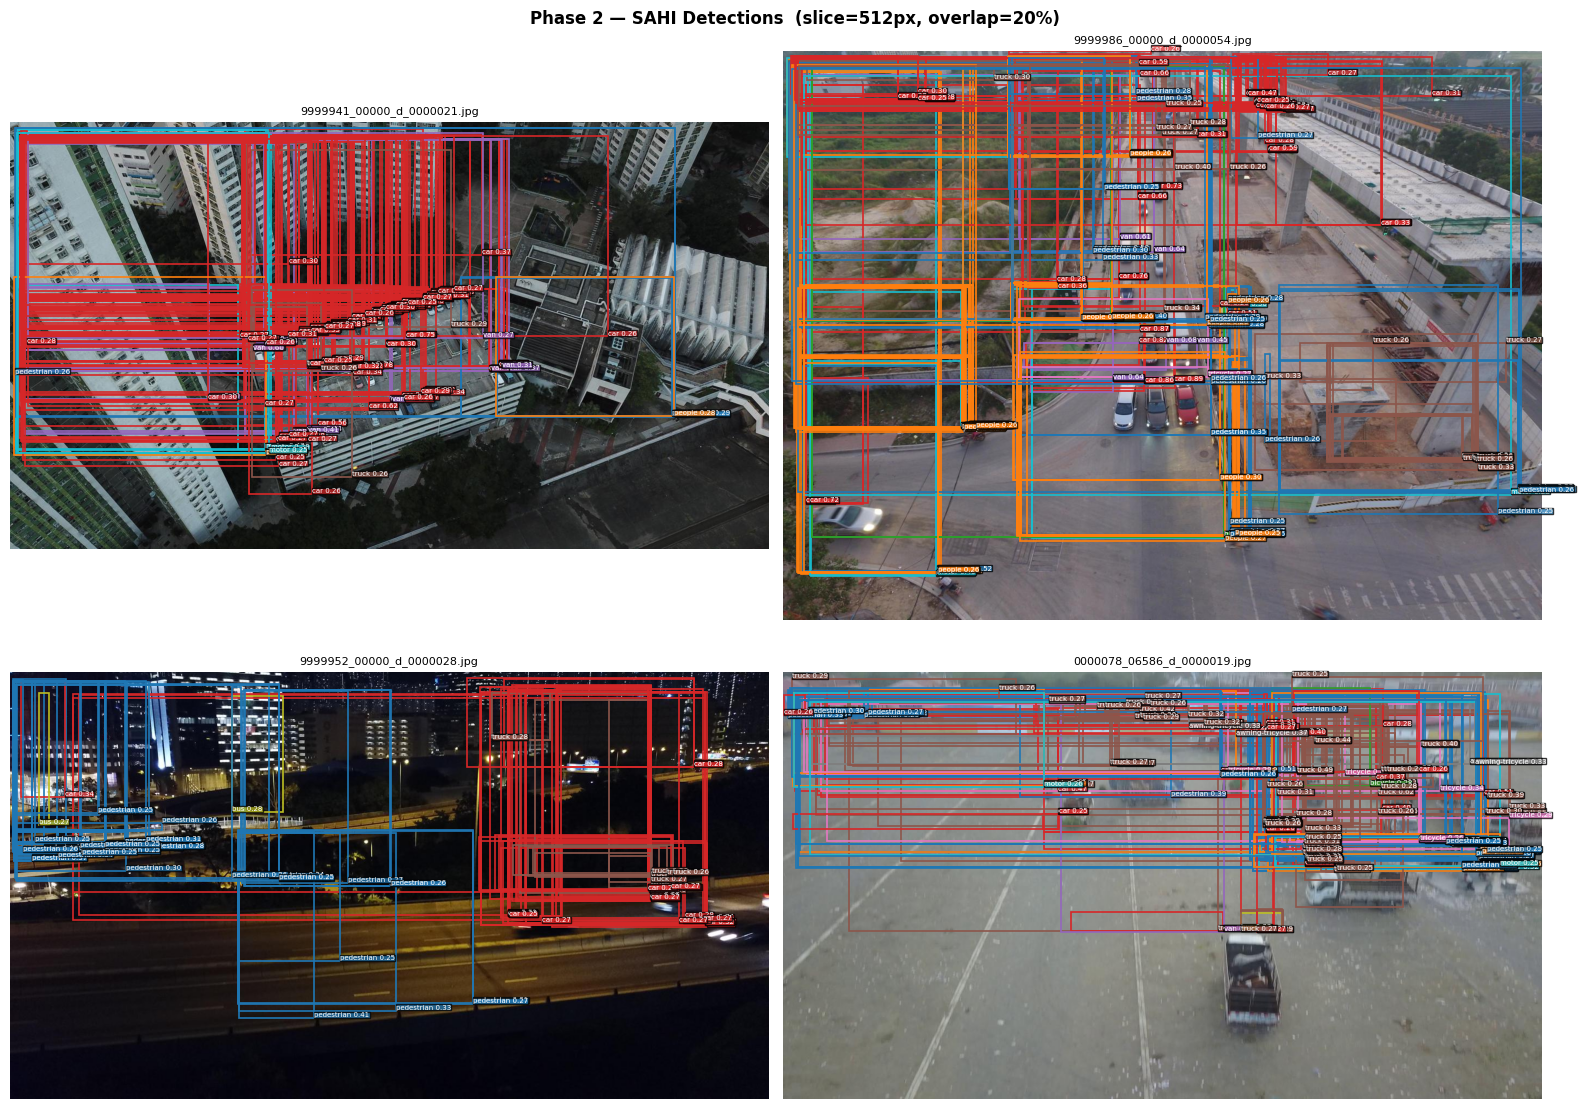

[Phase 2] Visualization saved → /kaggle/working/sahi_results/sahi_sample_predictions.png


In [13]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image as PILImage

random.seed(0)
sample_imgs = random.sample(gt['images'], 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes   = axes.flatten()
COLORS = plt.colormaps['tab10']

for ax, img_info in zip(axes, sample_imgs):
    img_path = os.path.join(IMG_DIR, img_info['file_name'])
    pil_img  = PILImage.open(img_path).convert('RGB')
    ax.imshow(np.array(pil_img))
    ax.set_title(img_info['file_name'], fontsize=8)
    ax.axis('off')

    result = get_sliced_prediction(
        image                       = img_path,
        detection_model             = detection_model,
        slice_height                = SLICE_SIZE,
        slice_width                 = SLICE_SIZE,
        overlap_height_ratio        = OVERLAP_RATIO,
        overlap_width_ratio         = OVERLAP_RATIO,
        postprocess_type            = 'NMS',
        postprocess_match_metric    = 'IOU',
        postprocess_match_threshold = IOU_THRESHOLD,
        verbose                     = 0,
    )

    for pred in result.object_prediction_list:
        x, y, w, h = pred.bbox.to_xywh()
        color = COLORS(pred.category.id % 10)
        ax.add_patch(patches.Rectangle(
            (x, y), w, h, linewidth=1.2, edgecolor=color, facecolor='none'))
        ax.text(x, y - 2,
                f"{pred.category.name} {pred.score.value:.2f}",
                fontsize=5, color='white',
                bbox=dict(boxstyle='square,pad=0', fc=color, alpha=0.75))

plt.suptitle(
    f"Phase 2 — SAHI Detections  (slice={SLICE_SIZE}px, overlap={int(OVERLAP_RATIO*100)}%)",
    fontsize=12, fontweight='bold')
plt.tight_layout()
viz_path = os.path.join(SAHI_OUTPUT_DIR, 'sahi_sample_predictions.png')
plt.savefig(viz_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"[Phase 2] Visualization saved → {viz_path}")


## Phase 2 — Complete ✅

**All output files are in `/kaggle/working/sahi_results/`:**

| File | Description |
|------|-------------|
| `sahi_coco_predictions.json` | Raw COCO-format predictions from SAHI |
| `phase2_metrics.json` | mAP@0.5, AP_S, AP_M, AR, FPS (Phase 2) |
| `phase2_per_class_ap.json` | Per-class AP@0.5 for all 10 VisDrone categories |
| `phase1_vs_phase2_delta.csv` | ΔAP_S · ΔRecall · ΔFPS (Phase 1 → Phase 2) |
| `sahi_sample_predictions.png` | Visual verification on 4 sample images |

**Next steps for the paper:**
1. Fill `PHASE1_METRICS` in Step 11 with your real Phase 1 numbers and re-run.
2. Repeat this notebook for the other 5 models:
   - GOLD-YOLO · DAMO-YOLO · NanoDet+ · YOLOv12n · RF-DETR
3. Aggregate ΔAP_S per model → **SAHI Impact Bar chart**
4. Build the **Model × Category AP_S heatmap** (Phase 1 vs Phase 2)
5. Final model ranking: accuracy / speed / edge deployment
